# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** A.TEJA SRI
**Register Number:** AP24110011545
**Date:** 25-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [ ]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [ ]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [ ]:
# Write your answer here
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

np.random.seed(42)
missing_indices=np.random.choice(tips.index,size=5,replace=False)
tips_missing=tips.copy()
tips_missing.loc[missing_indices,'tip']=np.nan
print("Misssing values: ",tips_missing['tip'].isna().sum())
tip_medians = tips_missing.groupby('time')['tip'].transform('median')

tips_filled = tips_missing.copy()

tips_filled['tip'] = tips_missing['tip'].fillna(tip_medians)

print("Remaining missing:", tips_filled['tip'].isna().sum())



Misssing values:  5
Remaining missing: 0


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:* Example: Dinner tips may usually be higher than lunch tips. So, for a missing dinner tip, using the Dinner median is more accurate than using one global median for all tips.


## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [ ]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [ ]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']]


,day,day_Thur,day_Thur,day_Fri,day_Fri,day_Sat,day_Sat,day_Sun,day_Sun
0,Sun,False,False,False,False,False,False,True,True
1,Sun,False,False,False,False,False,False,True,True
2,Sun,False,False,False,False,False,False,True,True
3,Sun,False,False,False,False,False,False,True,True
4,Sun,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...
239,Sat,False,False,False,False,True,True,False,False
240,Sat,False,False,False,False,True,True,False,False
241,Sat,False,False,False,False,True,True,False,False
242,Sat,False,False,False,False,True,True,False,False


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*
Label encoding

Because time has only 2 categories (Lunch, Dinner), we can simply convert them to 0 and 1.

In [ ]:

# Label encode the 'time' column
tips_enc['time_encoded'] = tips_enc['time'].map({
    'Lunch': 0,
    'Dinner': 1
})

# Check the result
tips_enc[['time', 'time_encoded']].head()

,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*
Because it creates a fake numerical order:
Thur=0 < Fri=1 < Sat=2 < Sun=3

A model may think Sunday is “greater” than Saturday, even though the days have no meaningful numerical order. One-hot encoding avoids this problem.

## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [ ]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000000,244.000000
mean,19.785943,0.350145
std,8.902412,0.186477
min,3.070000,0.000000
25%,13.347500,0.215281
50%,17.795000,0.308442
75%,24.127500,0.441087
max,50.810000,1.000000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [ ]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000000,2.440000e+02
mean,19.785943,-6.028875e-17
std,8.902412,1.000000e+00
min,3.070000,-1.877687e+00
25%,13.347500,-7.232245e-01
50%,17.795000,-2.236408e-01
75%,24.127500,4.876833e-01
max,50.810000,3.484905e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:* my predicyion is mean =0 std=1

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [ ]:
# Check the original mean
print(tips_enc['total_bill'].mean())

# Check the standardized mean
print(tips_enc['total_bill_standardized'].mean())

# Check the standardized standard deviation
print(tips_enc['total_bill_standardized'].std())

19.78594262295082
-6.028875031263658e-17
1.0


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:* Min-max scaling changes values to a fixed range (usually 0–1) but is highly affected by extreme outliers.
Standardization gives mean = 0 and standard deviation = 1, so it is usually preferred when outliers are present.


## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [ ]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


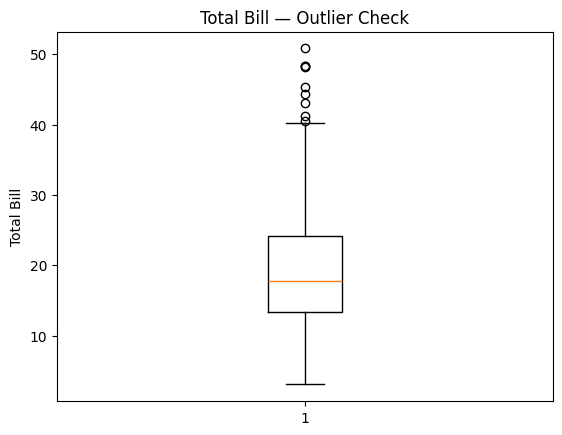

In [ ]:
# Visualize outliers with a boxplot
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [ ]:
# Write your answer here
# Find the 25th percentile (Q1)

import pandas as pd
import seaborn as sns

# Load the tips dataset
df = sns.load_dataset("tips")



Q1 = df["tip"].quantile(0.25)

# Find the 75th percentile (Q3)
Q3 = df["tip"].quantile(0.75)

# IQR = middle 50% of the data
IQR = Q3 - Q1

# Lower limit for detecting outliers
lower_bound = Q1 - 1.5 * IQR

# Upper limit for detecting outliers
upper_bound = Q3 + 1.5 * IQR

# Show the limits
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Find values that are outside these limits
outliers = df[(df["tip"] < lower_bound) | (df["tip"] > upper_bound)]

print("Number of outliers:", len(outliers))
print(outliers["tip"])

Lower bound: -0.34375
Upper bound: 5.90625
Number of outliers: 9
23      7.58
47      6.00
59      6.73
141     6.70
170    10.00
183     6.50
212     9.00
214     6.50
239     5.92
Name: tip, dtype: float64


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:* Capping keeps all the data and reduces the effect of extreme values, so we don't lose useful rows. Dropping is better when the outlier is clearly an error or when it is not meaningful for the analysis.


## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [ ]:


from sklearn.model_selection import train_test_split


X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


0       5.944673
1      16.054159
2      16.658734
3      13.978041
4      14.680765
         ...    
239    20.392697
240     7.358352
241     8.822232
242     9.820426
243    15.974441
Name: tip_pct, Length: 244, dtype: float64


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']

tips_enc = tips.copy()
tips_enc['tip_pct'] = (tips_enc['tip'] / tips_enc['total_bill']) * 100


tips_enc['sex_encoded'] = tips_enc['sex'].map({
    'Male': 0,
    'Female': 1
})


tips_enc['smoker_encoded'] = tips_enc['smoker'].map({
    'No': 0,
    'Yes': 1
})

tips_enc['total_bill_scaled'] = (
    tips_enc['total_bill'] - tips_enc['total_bill'].min()
) / (
    tips_enc['total_bill'].max() - tips_enc['total_bill'].min()
)


X = tips_enc[['total_bill_scaled', 'size', 'sex_encoded', 'smoker_encoded']]


y = tips_enc['tip_pct']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 170
Testing rows: 74


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:* We split before training to prevent data leakage, so the test set stays unseen and gives an honest measure of how well the model works on new data.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving hanuman.png to hanuman.png


In [ ]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [ ]:
# Write your answer here

from PIL import Image
import numpy as np
import pandas as pd


normalized_images = []


results = []

for filename in filenames:

    img = np.array(Image.open(filename))


    min_before = img.min()
    max_before = img.max()


    normalized = img / 255.0


    normalized_images.append(normalized)


    min_after = normalized.min()
    max_after = normalized.max()

    results.append({
        "filename": filename,
        "min_pixel_before": min_before,
        "max_pixel_before": max_before,
        "min_pixel_after": min_after,
        "max_pixel_after": max_after
    })


normalization_df = pd.DataFrame(results)

print(normalization_df)

      filename  min_pixel_before  max_pixel_before  min_pixel_after  \
0  hanuman.png                 0               255              0.0   

   max_pixel_after  
0              1.0  


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [ ]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [ ]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd


processed_images = []

results = []

for filename in filenames:


    img = Image.open(filename)


    img = img.resize((128, 128))


    img_array = np.array(img)

    img_array = img_array / 255.0


    processed_images.append(img_array)

    results.append({
        "filename": filename,
        "shape": img_array.shape
    })


shape_df = pd.DataFrame(results)


print(shape_df)

      filename          shape
0  hanuman.png  (128, 128, 4)


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:* Because a model expects the same number of input values from every image; different-sized images cause a shape/dimension error, so the model cannot process them together.


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [ ]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [ ]:

sentence = "hello my name is rekha :)"


sentence = sentence.lower()


import re
sentence = re.sub(r'[^a-z0-9\s]', '', sentence)

tokens = sentence.split()

print(tokens)

['hello', 'my', 'name', 'is', 'rekha']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [ ]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [ ]:
# Write your answer here

tokens = ['hii', 'i', 'love', 'python', 'but', 'im', 'learning', 'it', 'in', '2026']


word_to_id = {word: i for i, word in enumerate(tokens)}


encoded_tokens = [word_to_id[word] for word in tokens]


print("Word to ID:", word_to_id)
print("Encoded tokens:", encoded_tokens)

import pandas as pd

mapping_df = pd.DataFrame(
    list(word_to_id.items()),
    columns=['word', 'id']
)


mapping_df = mapping_df.sort_values('id')

print(mapping_df)

Word to ID: {'hii': 0, 'i': 1, 'love': 2, 'python': 3, 'but': 4, 'im': 5, 'learning': 6, 'it': 7, 'in': 8, '2026': 9}
Encoded tokens: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
       word  id
0       hii   0
1         i   1
2      love   2
3    python   3
4       but   4
5        im   5
6  learning   6
7        it   7
8        in   8
9      2026   9


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:* Yes—the same problem applies: IDs create a fake order between words (e.g., love=2 and python=3 makes 3 seem “greater” than 2), even though words have no natural numerical order.


# Final Self-Check

- [x] I handled missing data using a justified strategy, not just dropped everything blindly
- [x] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [x] I scaled numeric features and can explain the difference between min-max and standardization
- [x] I detected outliers using IQR and handled them (capped, not just deleted)
- [x] I split data into train/test sets correctly
- [x] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [x] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
